In [1]:
import os

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

In [3]:
# Load data
data = pd.read_csv("../data/processed/final_dataset_numeric.csv")

In [4]:
MAIN_FEATURES = [
    'age',
    'gender',
    'smoker',
    'known_blood_sugar',
    'known_cholesterol',
    'under_treatment',
    'health_condition',
]

In [5]:
def train_rf_model(X_train, X_test, y_train, y_test):
    print(f"\nTraining set : {len(X_train):,} rows")
    print(f"Test set     : {len(X_test):,} rows")
    
    # Build RF model
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,max_depth=None
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    return rf, y_pred

In [6]:
def plot_actual_vs_predicted(y_true, y_pred, title, save_path=None):
    plt.figure(figsize=(6,5))
    
    plt.scatter(y_true, y_pred, alpha=0.4, s=15, color='teal')
    
    # Perfect prediction line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)

    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

def plot_feature_importance(importance_df, title, save_path=None):
    plt.figure(figsize=(6,5))
    
    plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
    
    plt.xlabel('Importance')
    plt.title(title)
    plt.gca().invert_yaxis()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

### Dialstolic BP Prediction

In [7]:
FEATURES = MAIN_FEATURES.copy()
FEATURES.extend(['bp_systolic'])
X = data[FEATURES]
y = data['bp_diastolic']

In [8]:
# Train/Test Split
(X_train, X_test,
 y_train, y_test) = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    
)

In [9]:
rf, y_pred = train_rf_model(X_train, X_test, y_train, y_test)

# Cross-validation
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Diastolic):", scores)
print("Mean CV R²:", scores.mean())


Training set : 12,175 rows
Test set     : 3,044 rows
Cross-validated R² scores (Diastolic): [0.48865302 0.46051188 0.4196023  0.45665475 0.42360965]
Mean CV R²: 0.4498063179864532


In [10]:
# Evaluate the model
r2_dia = r2_score(y_test, y_pred)
mae_dia = mean_absolute_error(y_test, y_pred)
rmse_dia = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"Diastolic BP R²: {r2_dia:.3f}, MAE: {mae_dia:.2f}, RMSE: {rmse_dia:.2f}")

# Feature Importance
imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp.to_string(index=False))

--- Model Evaluation ---
Diastolic BP R²: 0.479, MAE: 7.73, RMSE: 10.52

Feature Importance:
          feature  importance
      bp_systolic    0.763533
              age    0.162284
           gender    0.020977
 health_condition    0.020427
  under_treatment    0.012036
known_cholesterol    0.007704
           smoker    0.006545
known_blood_sugar    0.006492


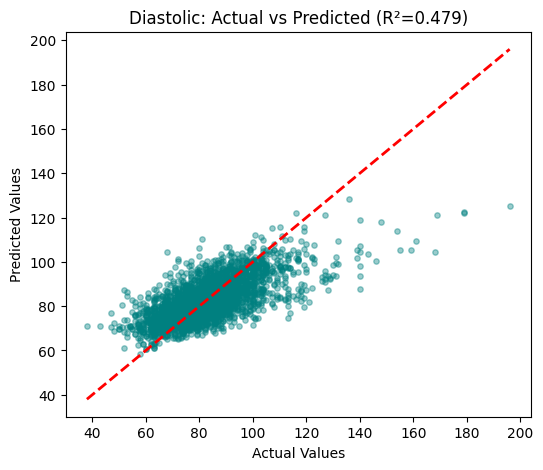

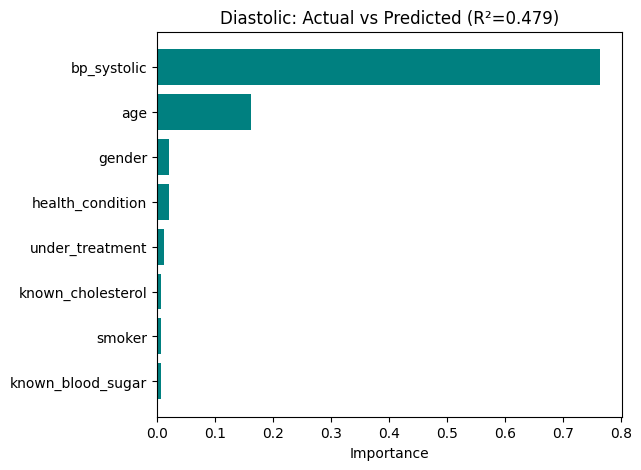


MODEL SUMMARY
                           Diastolic
R²                            0.4785
MAE (mmHg)                      7.73
RMSE (mmHg)                    10.52


In [11]:
plot_actual_vs_predicted(y_test, y_pred, title=f'Diastolic: Actual vs Predicted (R²={r2_dia:.3f})', save_path='../presentation/figures/bp_dia_prediction_fig.png')
plot_feature_importance(imp, title=f'Diastolic: Actual vs Predicted (R²={r2_dia:.3f})', save_path='../presentation/figures/bp_dia_featimp_fig.png')

# Summary 
print("\n" + "="*45)
print("MODEL SUMMARY")
print("="*45)
print(f"{'':25} {'Diastolic':>10}")
print(f"{'R²':25} {r2_dia:>10.4f}")
print(f"{'MAE (mmHg)':25} {mae_dia:>10.2f}")
print(f"{'RMSE (mmHg)':25} {rmse_dia:>10.2f}")

### Systolic BP Prediction

In [12]:
FEATURES = MAIN_FEATURES.copy()
FEATURES.extend(['bp_diastolic'])
X = data[FEATURES]
y = data['bp_systolic']

In [13]:
# Train/Test Split
(X_train, X_test,
 y_train, y_test) = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    
)

In [14]:
rf, y_pred = train_rf_model(X_train, X_test, y_train, y_test)

# Cross-validation
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R² scores (Diastolic):", scores)
print("Mean CV R²:", scores.mean())


Training set : 12,175 rows
Test set     : 3,044 rows
Cross-validated R² scores (Diastolic): [0.54227939 0.48821063 0.47894034 0.51952046 0.47861488]
Mean CV R²: 0.5015131403500587


In [15]:
# Evaluate the model
r2_sys = r2_score(y_test, y_pred)
mae_sys = mean_absolute_error(y_test, y_pred)
rmse_sys = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"Systolic BP R²: {r2_sys:.3f}, MAE: {mae_sys:.2f}, RMSE: {rmse_sys:.2f}")

# Feature Importance
imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp.to_string(index=False))

--- Model Evaluation ---
Systolic BP R²: 0.526, MAE: 10.31, RMSE: 13.18

Feature Importance:
          feature  importance
     bp_diastolic    0.665923
              age    0.211626
  under_treatment    0.056052
           gender    0.024952
 health_condition    0.016818
known_cholesterol    0.009390
known_blood_sugar    0.009243
           smoker    0.005996


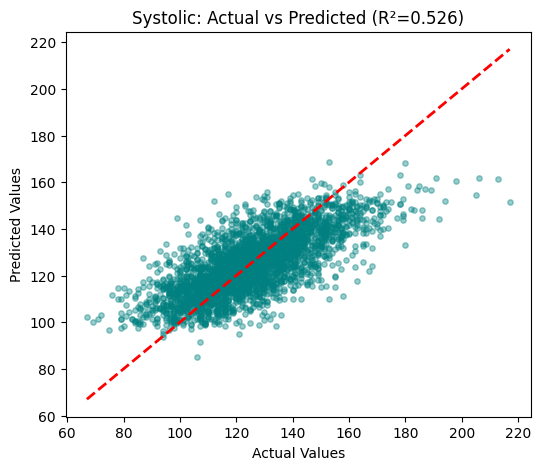

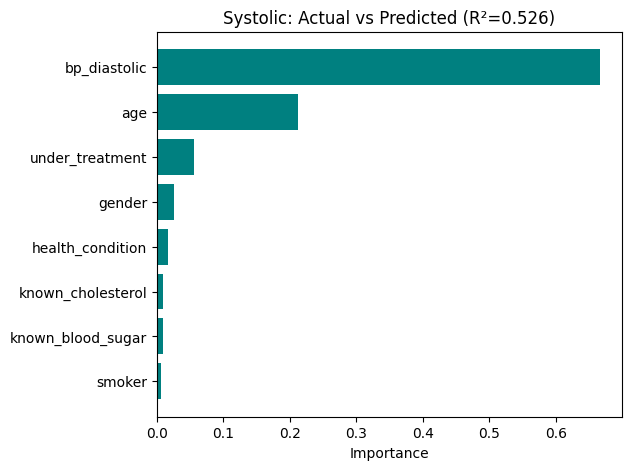


MODEL SUMMARY
                            Systolic
R²                            0.5264
MAE (mmHg)                     10.31
RMSE (mmHg)                    13.18


In [16]:
plot_actual_vs_predicted(y_test, y_pred, title=f'Systolic: Actual vs Predicted (R²={r2_sys:.3f})', save_path='../presentation/figures/bp_sys_prediction_fig.png')
plot_feature_importance(imp, title=f'Systolic: Actual vs Predicted (R²={r2_sys:.3f})', save_path='../presentation/figures/bp_sys_featimp_fig.png')

# Summary 
print("\n" + "="*45)
print("MODEL SUMMARY")
print("="*45)
print(f"{'':25} {'Systolic':>10}")
print(f"{'R²':25} {r2_sys:>10.4f}")
print(f"{'MAE (mmHg)':25} {mae_sys:>10.2f}")
print(f"{'RMSE (mmHg)':25} {rmse_sys:>10.2f}")

### Multi target output

In [17]:
X = data[MAIN_FEATURES]
y = data[['bp_systolic', 'bp_diastolic']]  # multi-output target

In [18]:
# Train/Test Split
(X_train, X_test,
 y_train, y_test) = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42    
)

In [19]:
rf, y_pred = train_rf_model(X_train, X_test, y_train, y_test)


Training set : 12,175 rows
Test set     : 3,044 rows


--- Model Evaluation ---
Systolic BP R²: 0.118, MAE: 14.05, RMSE: 17.98
Diastolic BP R²: 0.018, MAE: 10.70, RMSE: 14.43

Feature Importance:
          feature  importance
              age    0.673348
  under_treatment    0.123412
           gender    0.083019
 health_condition    0.052752
known_blood_sugar    0.024567
known_cholesterol    0.024469
           smoker    0.018432


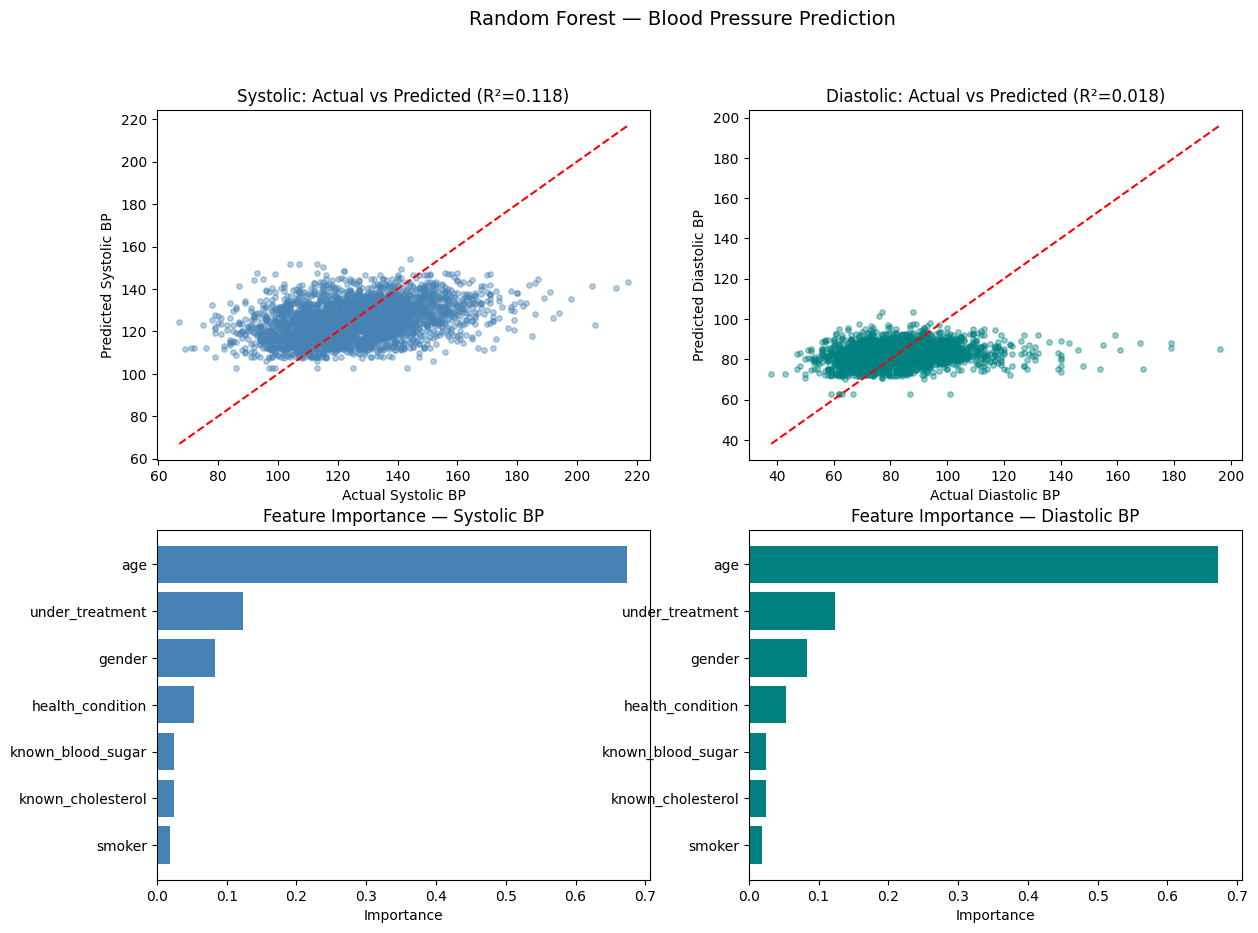


MODEL SUMMARY
                            Systolic  Diastolic
R²                            0.1183     0.0178
MAE (mmHg)                     14.05      10.70
RMSE (mmHg)                    17.98      14.43
Train size                    12,175
Test size                      3,044


In [20]:
# Evaluate the model
r2_sys = r2_score(y_test['bp_systolic'], y_pred[:,0])
r2_dia = r2_score(y_test['bp_diastolic'], y_pred[:,1])

mae_sys = mean_absolute_error(y_test['bp_systolic'], y_pred[:,0])
mae_dia = mean_absolute_error(y_test['bp_diastolic'], y_pred[:,1])

rmse_sys = np.sqrt(mean_squared_error(y_test['bp_systolic'], y_pred[:,0]))
rmse_dia = np.sqrt(mean_squared_error(y_test['bp_diastolic'], y_pred[:,1]))

print(f"--- Model Evaluation ---")
print(f"Systolic BP R²: {r2_sys:.3f}, MAE: {mae_sys:.2f}, RMSE: {rmse_sys:.2f}")
print(f"Diastolic BP R²: {r2_dia:.3f}, MAE: {mae_dia:.2f}, RMSE: {rmse_dia:.2f}")

# Feature Importance
imp = pd.DataFrame({
    'feature':    MAIN_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(imp.to_string(index=False))

# Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest — Blood Pressure Prediction', fontsize=14)

# Systolic: Actual vs Predicted
axes[0,0].scatter(y_test['bp_systolic'], y_pred[:,0], alpha=0.4, s=15, color='steelblue')
axes[0,0].plot([y_test['bp_systolic'].min(), y_test['bp_systolic'].max()],
               [y_test['bp_systolic'].min(), y_test['bp_systolic'].max()], 'r--', lw=1.5)
axes[0,0].set_xlabel('Actual Systolic BP')
axes[0,0].set_ylabel('Predicted Systolic BP')
axes[0,0].set_title(f'Systolic: Actual vs Predicted (R²={r2_sys:.3f})')

# Diastolic: Actual vs Predicted
axes[0,1].scatter(y_test['bp_diastolic'], y_pred[:,1], alpha=0.4, s=15, color='teal')
axes[0,1].plot([y_test['bp_diastolic'].min(), y_test['bp_diastolic'].max()],
               [y_test['bp_diastolic'].min(), y_test['bp_diastolic'].max()], 'r--', lw=1.5)
axes[0,1].set_xlabel('Actual Diastolic BP')
axes[0,1].set_ylabel('Predicted Diastolic BP')
axes[0,1].set_title(f'Diastolic: Actual vs Predicted (R²={r2_dia:.3f})')

# Feature importance — Systolic
axes[1,0].barh(imp['feature'], imp['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance')
axes[1,0].set_title('Feature Importance — Systolic BP')
axes[1,0].invert_yaxis()

# Feature importance — Diastolic
axes[1,1].barh(imp['feature'], imp['importance'], color='teal')
axes[1,1].set_xlabel('Importance')
axes[1,1].set_title('Feature Importance — Diastolic BP')
axes[1,1].invert_yaxis()

# Saving figure
fig_path = "../presentation/figures/bp_prediction_fig.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# Summary 
print("\n" + "="*45)
print("MODEL SUMMARY")
print("="*45)
print(f"{'':25} {'Systolic':>10} {'Diastolic':>10}")
print(f"{'R²':25} {r2_sys:>10.4f} {r2_dia:>10.4f}")
print(f"{'MAE (mmHg)':25} {mae_sys:>10.2f} {mae_dia:>10.2f}")
print(f"{'RMSE (mmHg)':25} {rmse_sys:>10.2f} {rmse_dia:>10.2f}")